# Dense ("linear") model → Mixture-of-Experts upcycling

ERA V5 MoE session, Section 21 assignment: **train a linear (dense) model, convert it into an MoE of your own design, and show that it continues to train and reduces loss.**

The design follows the course notes (section numbers in brackets):

| Decision | What this notebook does |
|---|---|
| Expert shape [§3] | SwiGLU feed-forward networks (gate, up, down), no biases |
| Growing the model [§15] | `init_method` = **copy**, **partition** or **drop** (drop-upcycling, r = 0.5 is the default) |
| Shared expert [§8] | One always-on shared expert, taken from the first half of the dense network's neurons |
| Router [§7] | **Sigmoid** scores, top-k rescaled to sum to 1, fp32, initialised at 1/10 the usual scale, routed scaling factor when experts are narrower than the source |
| Early routing [§15] | **Probabilistic top-k** for the first steps, so near-identical clones all get gradient, then hard top-k |
| Balancing [§13, §20] | **Loss-free bias**, γ = 0.001, only for *choosing*, plus a tiny sequence-level loss (0.0001), counted over the whole batch [§14] |
| Capacity [§11] | **Dropless**: no token is dropped |
| Balance metric [§10] | **MaxVio** = (busiest load − average) / average, per layer |

**Continuity at conversion.** `copy` reproduces the dense model exactly, so the loss doesn't move. `drop` and `partition` make the experts different on purpose, which costs a small one-off bump (+0.05 in the first Colab run) that recovers quickly. The assignment is met when the MoE curve carries on falling after the conversion line.

**Data.** The default is a 22 MB slice of **TinyStories**, about 20× more text than TinyShakespeare. On Shakespeare the model had seen the text about 20 times by the conversion point, so it started memorising, and validation loss rose after conversion for *both* the dense and MoE branches. With TinyStories the model sees each character less than twice, so validation loss keeps falling.

**Sections 1–10** train the dense model once, convert it, and compare. **Section 11** reuses that dense model to run the comparison experiments and builds one results table.

**Before running:** Runtime → Change runtime type → **T4 GPU**. Sections 1–10 take about 15 minutes on a T4, and section 11 adds roughly 30 minutes.

In [1]:
import os, math, time, copy, urllib.request
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(1337)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = True
print("device:", device, torch.cuda.get_device_name(0) if device == "cuda" else "(no GPU: switch the runtime to T4)")

device: cuda Tesla T4


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuration
Everything you might want to experiment with lives here.

In [2]:
QUICK = os.environ.get("QUICK") == "1"   # tiny smoke-test run; leave off in Colab

# --- data ---
dataset = "tinystories"       # "tinystories" (22.5M chars) | "shakespeare" (1.1M chars, overfits after ~1 epoch)

# --- dense ("linear") model ---
block_size, batch_size = 128, 64
n_layer, n_head, n_embd = 4, 4, 256
ffn_mult = 3                  # SwiGLU inner width = 3 * n_embd = 768 (Qwen3 uses 6,144 for 2,048)
dropout = 0.1
dense_iters, lr_dense = 2500, 1e-3

# --- growing into an MoE [§15] ---
n_experts, top_k = 8, 2       # routed experts per layer, experts per token
use_shared = True             # shared expert = first half of the dense neurons; routed experts come from the other half
init_method = "drop"          # "copy" | "partition" | "drop"
drop_ratio = 0.5              # drop: fraction of each expert's neurons redrawn (r = 0.5 was best)
zero_init_dropped = True      # drop: redrawn neurons start with zero down-projection -> smaller bump
part_frac = 0.5               # partition: each expert takes an overlapping random slice of this fraction of neurons
copy_noise = 0.0              # copy: optional relative noise; 0 keeps conversion exact

# --- router [§7] ---
score_fn = "sigmoid"          # "sigmoid" | "softmax"
router_init_std = 0.002       # one tenth of the usual 0.02
prob_topk_iters = 200         # probabilistic top-k for the first N steps, then hard top-k

# --- balancing [§12-§14] ---
balance = "lossfree"          # "lossfree" | "aux" | "none"
bias_gamma = 1e-3             # loss-free bias update speed
seq_aux_alpha = 1e-4          # tiny sequence-level loss kept alongside the bias (DeepSeek-V3 recipe); 0 to disable
aux_alpha = 1e-2              # Switch-style batch loss, only when balance == "aux"

# --- continued training (dense and MoE branches get the same budget) ---
cont_iters, lr_cont, warmup = 2000, 3e-4, 100
eval_every, eval_batches = 100, 20

if QUICK:
    batch_size, n_embd, n_head = 16, 64, 4
    dense_iters, cont_iters, eval_every, eval_batches, prob_topk_iters, warmup = 60, 60, 20, 4, 20, 10

## 2. Data (character level)
TinyStories by default. Point `DATASETS` at any text file you like; the rest of the notebook doesn't care.

In [3]:
from collections import Counter
DATASETS = {
    "shakespeare": ("input.txt", "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"),
    "tinystories": ("tinystories_valid.txt", "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-valid.txt"),
}
fname, url = DATASETS[dataset]
if not os.path.exists(fname):
    print("downloading", url)
    urllib.request.urlretrieve(url, fname)
text = open(fname, encoding="utf-8").read().replace("<|endoftext|>", "\n")
# fold very rare characters (stray unicode) into "?" so the vocabulary stays small
counts = Counter(text)
rare = {c for c, k in counts.items() if k < 50}
if rare:
    text = text.translate({ord(c): "?" for c in rare})
chars = sorted(set(text)); vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}; itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9 * len(data)); train_data, val_data = data[:n], data[n:]
print(f"{dataset}: {len(text):,} characters, vocab {vocab_size}, "
      f"{dense_iters * batch_size * block_size / len(train_data):.1f} passes over the training text in the dense stage")

def get_batch(split, gen=None):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,), generator=gen)
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)

# fixed validation batches, so "loss before" and "loss after" conversion are measured on identical data
_g = torch.Generator().manual_seed(0)
val_set = [get_batch("val", _g) for _ in range(eval_batches)]

downloading https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-valid.txt
tinystories: 22,161,827 characters, vocab 67, 1.0 passes over the training text in the dense stage


## 3. The dense model

A small GPT whose feed-forward block is a SwiGLU network, the same shape as each expert in the course's reference model [§3]:

`FFN(x) = W_down( SiLU(W_gate x) ⊙ W_up x )`

In [4]:
class SwiGLU(nn.Module):
    def __init__(self, d, hidden):
        super().__init__()
        self.gate = nn.Linear(d, hidden, bias=False)
        self.up = nn.Linear(d, hidden, bias=False)
        self.down = nn.Linear(hidden, d, bias=False)
    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))

class Attention(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.h, self.qkv, self.proj = h, nn.Linear(d, 3 * d), nn.Linear(d, d)
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = (t.view(B, T, self.h, C // self.h).transpose(1, 2) for t in self.qkv(x).split(C, 2))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True,
                                           dropout_p=dropout if self.training else 0.0)
        return self.proj(y.transpose(1, 2).reshape(B, T, C))

class Block(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(d), Attention(d, h)
        self.ln2, self.ffn = nn.LayerNorm(d), SwiGLU(d, ffn_mult * d)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        x = x + self.drop(self.attn(self.ln1(x)))
        return x + self.drop(self.ffn(self.ln2(x)))

class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok, self.pos = nn.Embedding(vocab_size, n_embd), nn.Embedding(block_size, n_embd)
        self.blocks = nn.ModuleList(Block(n_embd, n_head) for _ in range(n_layer))
        self.ln_f, self.head = nn.LayerNorm(n_embd), nn.Linear(n_embd, vocab_size, bias=False)
        self.apply(lambda m: nn.init.normal_(m.weight, std=0.02) if isinstance(m, (nn.Linear, nn.Embedding)) else None)
    def forward(self, idx, targets=None):
        x = self.tok(idx) + self.pos(torch.arange(idx.size(1), device=idx.device))
        for b in self.blocks:
            x = b(x)
        logits = self.head(self.ln_f(x))
        loss = None if targets is None else F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
        return logits, loss

## 4. The MoE layer [§7, §11, §13]

Per token:
1. **Score.** The router (fp32) gives one logit per expert, and sigmoid turns them into scores.
2. **Choose.** Add the balancing **bias**, then keep the top-k. Early in training this is sampled instead (probabilistic top-k).
3. **Weight.** Take the chosen experts' *raw* scores (no bias), rescale them to sum to 1, and multiply by the routed scaling factor.
4. **Combine.** `y = shared(x) + Σ wᵢ · Eᵢ(x)`

It is dropless: each expert simply processes however many tokens chose it.

In [5]:
class MoE(nn.Module):
    def __init__(self, shared, experts, d, routed_scale=1.0):
        super().__init__()
        self.shared = shared                        # always on (or None)
        self.experts = nn.ModuleList(experts)
        self.E, self.k, self.routed_scale = len(experts), top_k, routed_scale
        self.router = nn.Linear(d, self.E, bias=False)
        nn.init.normal_(self.router.weight, std=router_init_std)
        self.register_buffer("bal_bias", torch.zeros(self.E))
        self.register_buffer("load_acc", torch.zeros(self.E))
        self.prob_select = False
        self.aux_loss = torch.zeros(())

    def forward(self, x):
        B, T, C = x.shape
        x = x.reshape(-1, C); N = x.size(0)
        logits = self.router(x.float())                           # router in fp32
        s = torch.sigmoid(logits) if score_fn == "sigmoid" else logits.softmax(-1)
        sel = s + self.bal_bias if balance == "lossfree" else s   # bias only decides WHO
        if self.training and self.prob_select:                    # probabilistic top-k
            p = sel.clamp_min(1e-6); p = p / p.sum(-1, keepdim=True)
            idx = torch.multinomial(p, self.k)
        else:                                                     # hard top-k
            idx = sel.topk(self.k, dim=-1).indices
        w = s.gather(-1, idx)                                     # HOW MUCH: raw scores
        w = (self.routed_scale * w / w.sum(-1, keepdim=True)).to(x.dtype)

        out = self.shared(x) if self.shared is not None else torch.zeros_like(x)
        flat = idx.reshape(-1)
        tok = torch.arange(N, device=x.device).repeat_interleave(self.k)
        fw = w.reshape(-1)
        for e, expert in enumerate(self.experts):
            m = flat == e
            if m.any():
                t = tok[m]
                out = out.index_add(0, t, fw[m, None] * expert(x[t]))

        load = torch.bincount(flat, minlength=self.E).float()     # counted over the whole batch [§14]
        if self.training:
            self.last_load = load
            self.load_acc += load

        s_norm = s / s.sum(-1, keepdim=True)
        if balance == "aux":                                      # Switch loss: N * sum f_i P_i [§12]
            f = load / (N * self.k)
            self.aux_loss = aux_alpha * self.E * (f * s_norm.mean(0)).sum()
        elif balance == "lossfree" and seq_aux_alpha > 0:         # tiny per-sequence loss [§13]
            counts = F.one_hot(idx.view(B, T * self.k), self.E).sum(1).float()     # (B, E)
            f = counts * self.E / (self.k * T)
            P = s_norm.view(B, T, self.E).mean(1)
            self.aux_loss = seq_aux_alpha * (f * P).sum(-1).mean()
        else:
            self.aux_loss = torch.zeros((), device=x.device)
        return out.reshape(B, T, C)

    @torch.no_grad()
    def update_bias(self):
        l = self.last_load                     # busier than average -> bias down, quieter -> bias up
        self.bal_bias += bias_gamma * torch.sign(l.mean() - l)

def moe_layers(model):
    return [m for m in model.modules() if isinstance(m, MoE)]

## 5. Growing: dense SwiGLU → shared expert + routed experts [§15]

With `use_shared = True` the dense network's inner neurons are split in half. The **shared expert** takes neurons `[0 : H/2]`, and the routed experts are built from the other half, which we call the *source*:

| `init_method` | Each routed expert starts as | Conversion |
|---|---|---|
| `copy` | the whole source (sparse upcycling) | exact, because the top-k weights sum to 1 |
| `partition` | an overlapping random `part_frac` slice of the source neurons; outputs × `1/part_frac` (routed scaling factor) | close; the experts start different |
| `drop` | the whole source with a fraction `drop_ratio` of its neurons redrawn | close; the experts start near each other but different |

With `use_shared = False` the source is the whole dense network.

In [6]:
def swiglu_from(src, idx):
    new = SwiGLU(src.gate.in_features, len(idx)).to(src.gate.weight.device)
    with torch.no_grad():
        new.gate.weight.copy_(src.gate.weight[idx])
        new.up.weight.copy_(src.up.weight[idx])
        new.down.weight.copy_(src.down.weight[:, idx])
    return new

def make_experts(src, source_idx):
    Hs = len(source_idx)
    experts = []
    for _ in range(n_experts):
        if init_method == "partition":
            pick = source_idx[torch.randperm(Hs)[: int(part_frac * Hs)]]
            experts.append(swiglu_from(src, pick.sort().values))
            continue
        e = swiglu_from(src, source_idx)
        with torch.no_grad():
            if init_method == "drop":
                redraw = torch.randperm(Hs)[: int(drop_ratio * Hs)]
                e.gate.weight[redraw] = torch.randn_like(e.gate.weight[redraw]) * 0.02
                e.up.weight[redraw] = torch.randn_like(e.up.weight[redraw]) * 0.02
                e.down.weight[:, redraw] = 0.0 if zero_init_dropped else torch.randn_like(e.down.weight[:, redraw]) * 0.02
            elif copy_noise > 0:
                for p in e.parameters():
                    p.add_(copy_noise * p.std() * torch.randn_like(p))
        experts.append(e)
    return experts

def upcycle(dense_model):
    moe_model = copy.deepcopy(dense_model)
    for b in moe_model.blocks:
        src = b.ffn; H = src.gate.out_features
        if use_shared:
            shared = swiglu_from(src, torch.arange(H // 2))
            source_idx = torch.arange(H // 2, H)
        else:
            shared, source_idx = None, torch.arange(H)
        scale = 1 / part_frac if init_method == "partition" else 1.0
        b.ffn = MoE(shared, make_experts(src, source_idx), n_embd, routed_scale=scale).to(device)
    return moe_model

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    idle = sum((m.E - m.k) * sum(p.numel() for p in m.experts[0].parameters()) for m in moe_layers(model))
    return total, total - idle

## 6. Training utilities

In [7]:
@torch.no_grad()
def eval_loss(model):
    model.eval()
    l = sum(model(x, y)[1].item() for x, y in val_set) / len(val_set)
    model.train()
    return l

def train(model, iters, lr, warm, step0, log, tag):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)
    moes = moe_layers(model)
    t0 = time.time()
    for it in range(iters + 1):
        if it % eval_every == 0 or it == iters:
            v = eval_loss(model); log["val"].append((step0 + it, v))
            msg = f"[{tag}] step {step0 + it:5d}  val {v:.4f}"
            if moes:
                shares = torch.stack([m.load_acc / m.load_acc.sum().clamp_min(1) for m in moes]).cpu()
                log["load"].append((step0 + it, shares))
                for m in moes: m.load_acc.zero_()
                if it > 0:
                    msg += f"  MaxVio {(shares.max(-1).values * n_experts - 1).mean():.2f}"
            print(msg + f"  ({time.time() - t0:.0f}s)")
        if it == iters:
            break
        for m in moes:
            m.prob_select = it < prob_topk_iters
        frac = it / max(1, iters)       # linear warmup, then cosine decay to 10%
        lr_t = lr * min(1.0, (it + 1) / warm) * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * frac)))
        for g in opt.param_groups: g["lr"] = lr_t
        x, y = get_batch("train")
        _, loss = model(x, y)
        total = loss + sum(m.aux_loss for m in moes) if moes else loss
        opt.zero_grad(set_to_none=True)
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if balance == "lossfree":
            for m in moes: m.update_bias()
        log["train"].append((step0 + it, loss.item()))
    return model

@torch.no_grad()
def sample(model, n=300):
    model.eval()
    idx = torch.zeros((1, 1), dtype=torch.long, device=device)
    for _ in range(n):
        logits, _ = model(idx[:, -block_size:])
        idx = torch.cat([idx, torch.multinomial(logits[:, -1].softmax(-1), 1)], 1)
    model.train()
    return "".join(itos[i] for i in idx[0].tolist())

## 7. Stage 1: train the dense model

In [8]:
dense = GPT().to(device)
log_dense = {"train": [], "val": [], "load": []}
train(dense, dense_iters, lr_dense, warmup, 0, log_dense, "dense")
torch.save(dense.state_dict(), "dense.pt")
print(sample(dense))

[dense] step     0  val 4.2499  (1s)
[dense] step   100  val 2.1825  (8s)
[dense] step   200  val 1.4708  (15s)
[dense] step   300  val 1.2583  (21s)
[dense] step   400  val 1.1515  (28s)
[dense] step   500  val 1.0789  (35s)
[dense] step   600  val 1.0310  (42s)
[dense] step   700  val 0.9929  (48s)
[dense] step   800  val 0.9645  (55s)
[dense] step   900  val 0.9362  (62s)
[dense] step  1000  val 0.9188  (69s)
[dense] step  1100  val 0.9010  (76s)
[dense] step  1200  val 0.8866  (83s)
[dense] step  1300  val 0.8718  (90s)
[dense] step  1400  val 0.8574  (97s)
[dense] step  1500  val 0.8448  (104s)
[dense] step  1600  val 0.8361  (111s)
[dense] step  1700  val 0.8267  (118s)
[dense] step  1800  val 0.8189  (126s)
[dense] step  1900  val 0.8108  (133s)
[dense] step  2000  val 0.8032  (140s)
[dense] step  2100  val 0.7993  (147s)
[dense] step  2200  val 0.7933  (154s)
[dense] step  2300  val 0.7898  (162s)
[dense] step  2400  val 0.7859  (169s)
[dense] step  2500  val 0.7848  (176s)


O

## 8. Stage 2: grow into an MoE and check continuity

Both numbers below use the same fixed validation batches. Expect a jump of about 0 with `copy`, and a small bump with `drop` or `partition`.

In [9]:
moe = upcycle(dense)
loss_before = eval_loss(dense)
loss_after = eval_loss(moe)
d_tot, d_act = count_params(dense)
m_tot, m_act = count_params(moe)
print(f"init: {init_method}   val loss  dense: {loss_before:.4f}   MoE right after conversion: {loss_after:.4f}   jump: {loss_after - loss_before:+.4f}")
print(f"params    dense: {d_tot / 1e6:.2f}M      MoE: {m_tot / 1e6:.2f}M total, {m_act / 1e6:.2f}M active per token")

init: drop   val loss  dense: 0.7848   MoE right after conversion: 0.8397   jump: +0.0549
params    dense: 3.48M      MoE: 11.75M total, 4.67M active per token


## 9. Stage 3: continue training both branches with the same budget
The dense branch is the control: did becoming an MoE actually help?

In [10]:
dense_cont = copy.deepcopy(dense)
log_dc = {"train": [], "val": [], "load": []}
log_moe = {"train": [], "val": [], "load": []}
train(dense_cont, cont_iters, lr_cont, warmup, dense_iters, log_dc, "dense-cont")
train(moe, cont_iters, lr_cont, warmup, dense_iters, log_moe, "moe")
torch.save(moe.state_dict(), "moe.pt")

[dense-cont] step  2500  val 0.7848  (0s)
[dense-cont] step  2600  val 0.7937  (8s)
[dense-cont] step  2700  val 0.7937  (15s)
[dense-cont] step  2800  val 0.7960  (23s)
[dense-cont] step  2900  val 0.7919  (30s)
[dense-cont] step  3000  val 0.7887  (37s)
[dense-cont] step  3100  val 0.7855  (45s)
[dense-cont] step  3200  val 0.7804  (52s)
[dense-cont] step  3300  val 0.7761  (60s)
[dense-cont] step  3400  val 0.7743  (67s)
[dense-cont] step  3500  val 0.7704  (75s)
[dense-cont] step  3600  val 0.7674  (82s)
[dense-cont] step  3700  val 0.7651  (90s)
[dense-cont] step  3800  val 0.7599  (97s)
[dense-cont] step  3900  val 0.7583  (105s)
[dense-cont] step  4000  val 0.7557  (112s)
[dense-cont] step  4100  val 0.7532  (120s)
[dense-cont] step  4200  val 0.7510  (127s)
[dense-cont] step  4300  val 0.7494  (135s)
[dense-cont] step  4400  val 0.7485  (142s)
[dense-cont] step  4500  val 0.7473  (150s)
[moe] step  2500  val 0.8397  (1s)
[moe] step  2600  val 0.8214  MaxVio 0.00  (14s)
[moe] st

## 10. Results

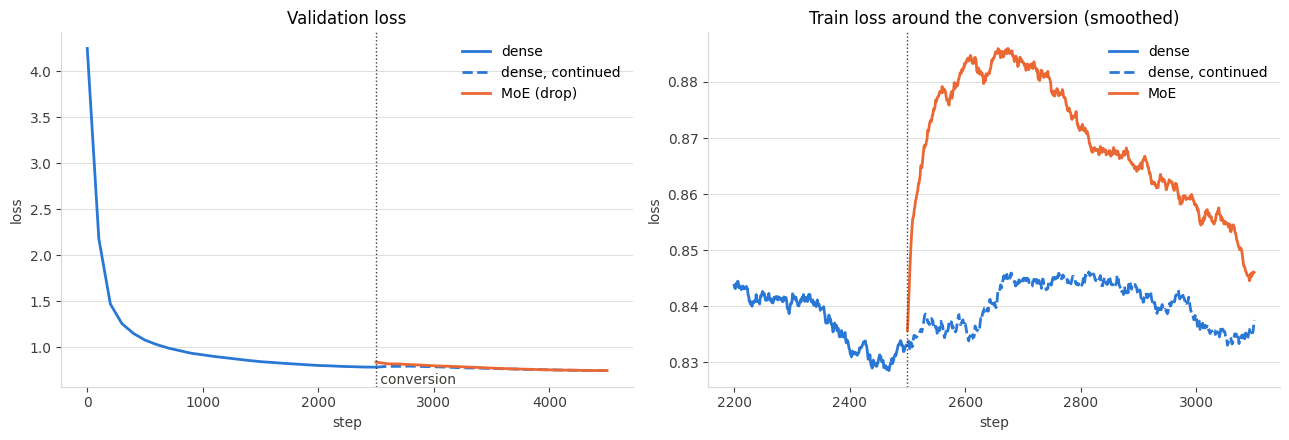

In [11]:
BLUE, ORANGE, GRID, INK = "#2a78d6", "#eb6834", "#d9d9d4", "#3d3d3a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRID,
                     "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK, "font.size": 10})

def ema(pts, v=None, a=0.98):
    out = []
    for s, l in pts:
        v = l if v is None else a * v + (1 - a) * l
        out.append((s, v))
    return out

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) validation loss, whole run
xs, ys = zip(*log_dense["val"]); ax1.plot(xs, ys, color=BLUE, lw=2, label="dense")
xs, ys = zip(*log_dc["val"]);    ax1.plot(xs, ys, color=BLUE, lw=2, ls="--", label="dense, continued")
xs, ys = zip(*log_moe["val"]);   ax1.plot(xs, ys, color=ORANGE, lw=2, label=f"MoE ({init_method})")
ax1.axvline(dense_iters, color=INK, lw=1, ls=":")
ax1.text(dense_iters, ax1.get_ylim()[0], " conversion", va="bottom", color=INK)
ax1.set(title="Validation loss", xlabel="step", ylabel="loss"); ax1.grid(axis="y", color=GRID, lw=0.6)
ax1.legend(frameon=False)

# (b) zoom: smoothed train loss around the conversion
tr_d = ema(log_dense["train"])
pre = [p for p in tr_d if p[0] >= max(0, dense_iters - 300)]
last = tr_d[-1][1]
hi = dense_iters + min(cont_iters, 600)
for pts, c, ls, lab in [(pre, BLUE, "-", "dense"),
                        (ema(log_dc["train"], last), BLUE, "--", "dense, continued"),
                        (ema(log_moe["train"], last), ORANGE, "-", "MoE")]:
    pts = [p for p in pts if p[0] <= hi]
    ax2.plot(*zip(*pts), color=c, ls=ls, lw=2, label=lab)
ax2.axvline(dense_iters, color=INK, lw=1, ls=":")
ax2.set(title="Train loss around the conversion (smoothed)", xlabel="step", ylabel="loss")
ax2.grid(axis="y", color=GRID, lw=0.6); ax2.legend(frameon=False)
plt.tight_layout(); plt.show()

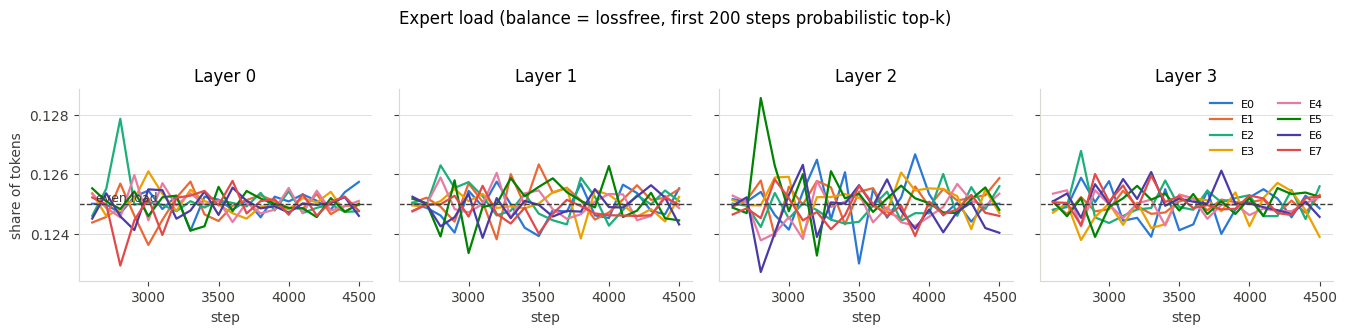

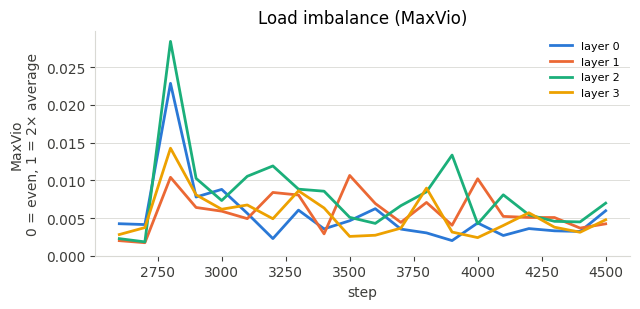

In [12]:
# expert load and MaxVio [§10]
EXPERT_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
steps = [s for s, _ in log_moe["load"]][1:]                    # first entry is before any training
shares = torch.stack([sh for _, sh in log_moe["load"]][1:])   # (T, layers, E)
L = shares.shape[1]
fig, axes = plt.subplots(1, L, figsize=(3.4 * L, 3.2), sharey=True)
axes = [axes] if L == 1 else list(axes)
for li, ax in enumerate(axes):
    for e in range(n_experts):
        ax.plot(steps, shares[:, li, e], color=EXPERT_COLORS[e % 8], lw=1.6, label=f"E{e}")
    ax.axhline(1 / n_experts, color=INK, lw=1, ls="--")
    ax.set(title=f"Layer {li}", xlabel="step"); ax.grid(axis="y", color=GRID, lw=0.6)
axes[0].set_ylabel("share of tokens")
axes[0].text(steps[0], 1 / n_experts, " even load", va="bottom", color=INK, fontsize=9)
axes[-1].legend(frameon=False, fontsize=8, ncol=2, loc="upper right")
fig.suptitle(f"Expert load (balance = {balance}, first {prob_topk_iters} steps probabilistic top-k)", y=1.03)
plt.tight_layout(); plt.show()

maxvio = shares.max(-1).values * n_experts - 1                 # (T, layers)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
for li in range(L):
    ax.plot(steps, maxvio[:, li], color=EXPERT_COLORS[li % 8], lw=2, label=f"layer {li}")
ax.set(title="Load imbalance (MaxVio)", xlabel="step",
       ylabel="MaxVio\n0 = even, 1 = 2× average"); ax.set_ylim(bottom=0)
ax.grid(axis="y", color=GRID, lw=0.6); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

In [13]:
final = shares[-1]
dead = int((final < 0.1 / n_experts).sum())
rows = [
    ("Growing method", init_method + (" + shared expert" if use_shared else "")),
    ("Params, dense", f"{d_tot / 1e6:.2f}M"),
    ("Params, MoE total / active", f"{m_tot / 1e6:.2f}M / {m_act / 1e6:.2f}M"),
    ("Val loss before conversion", f"{loss_before:.4f}"),
    ("Val loss right after conversion", f"{loss_after:.4f}  ({loss_after - loss_before:+.4f})"),
    ("Final val loss, dense continued", f"{log_dc['val'][-1][1]:.4f}"),
    ("Final val loss, MoE", f"{log_moe['val'][-1][1]:.4f}"),
    ("Final MaxVio (mean over layers)", f"{maxvio[-1].mean():.2f}"),
    ("Dead experts (<10% of even share)", f"{dead} of {final.numel()}"),
]
w = max(len(r[0]) for r in rows)
for k, v in rows:
    print(f"{k:<{w}}  {v}")
print("\nMoE sample:\n" + sample(moe))

Growing method                     drop + shared expert
Params, dense                      3.48M
Params, MoE total / active         11.75M / 4.67M
Val loss before conversion         0.7848
Val loss right after conversion    0.8397  (+0.0549)
Final val loss, dense continued    0.7473
Final val loss, MoE                0.7476
Final MaxVio (mean over layers)    0.01
Dead experts (<10% of even share)  0 of 32

MoE sample:

One day, Maggie and Sam were playing in the park. The button was hot and surprised. A girl saw the bus and said, "It can play with it again." The bug smiled at her and said, "I know what we can do, dog. It will have noxe stop medicine.”
Lila felt greedy because she didn't know who had become all the


## 11. Experiment runner

Every variant starts from the **same trained dense model** (from section 7), is converted with its own settings, and then trains for `EXP_ITERS` steps on the **same batches**. That makes the differences down to the setting, not luck. A dense model continued for the same steps is the control.

| Panel | Variants | Question | Course |
|---|---|---|---|
| Growing method | drop · copy · partition | Size of the bump, how fast it recovers, final loss | §15 |
| Clone collapse | copy · copy with hard top-k from step 0 | Do exact clones die without probabilistic top-k? | §15 |
| Balancing | loss-free bias · none · auxiliary loss | MaxVio and dead experts | §10, §12, §13 |
| Router & shared expert | sigmoid (baseline) · softmax · no shared expert | Effect on loss and balance | §7, §8 |
| Granularity | 8 experts top-2 · 16 experts top-4 (both partition, same active size) | More, smaller experts | §8 |

Edit `RUN` to run a subset. Results are saved to `experiments.csv` after every variant, so a Colab disconnect doesn't lose finished runs.

In [14]:
EXP_ITERS = 1000
if QUICK:
    EXP_ITERS = 40

VARIANTS = {   # name: settings that differ from section 1
    "drop (baseline)":     {},
    "copy":                {"init_method": "copy"},
    "partition":           {"init_method": "partition"},
    "copy, hard top-k":    {"init_method": "copy", "prob_topk_iters": 0},
    "no balancing":        {"balance": "none"},
    "aux loss":            {"balance": "aux"},
    "softmax router":      {"score_fn": "softmax"},
    "no shared expert":    {"use_shared": False},
    "16 experts, top-4":   {"init_method": "partition", "n_experts": 16, "top_k": 4, "part_frac": 0.25},
}
PANELS = {
    "Growing method":         ["drop (baseline)", "copy", "partition"],
    "Clone collapse":         ["copy", "copy, hard top-k"],
    "Balancing":              ["drop (baseline)", "no balancing", "aux loss"],
    "Router & shared expert": ["drop (baseline)", "softmax router", "no shared expert"],
    "Granularity":            ["partition", "16 experts, top-4"],
}
RUN = list(VARIANTS)

KNOBS = ["init_method", "prob_topk_iters", "balance", "score_fn", "use_shared", "n_experts", "top_k", "part_frac"]
DEFAULTS = {k: globals()[k] for k in KNOBS}

In [15]:
import pandas as pd

def load_stats(log):
    sh = torch.stack([s for _, s in log["load"]][1:])            # (evals, layers, experts)
    E = sh.shape[-1]
    maxvio = (sh.max(-1).values * E - 1).mean(-1)                # mean over layers
    dead = (sh < 0.1 / E).sum((-1, -2))                          # dead experts summed over layers
    return [s for s, _ in log["load"]][1:], maxvio, dead, sh.shape[1] * E

# control: dense model continued for the same number of steps
torch.manual_seed(1)
ctrl = copy.deepcopy(dense)
exp_logs = {"dense, continued": {"train": [], "val": [], "load": []}}
train(ctrl, EXP_ITERS, lr_cont, warmup, dense_iters, exp_logs["dense, continued"], "control")
ctrl_final = exp_logs["dense, continued"]["val"][-1][1]
del ctrl

rows = []
for name in RUN:
    globals().update(DEFAULTS); globals().update(VARIANTS[name])
    torch.manual_seed(0)
    m = upcycle(dense)
    after = eval_loss(m)
    tot, act = count_params(m)
    log = {"train": [], "val": [], "load": []}
    torch.manual_seed(1)                                          # same training batches for every variant
    train(m, EXP_ITERS, lr_cont, warmup, dense_iters, log, name)
    exp_logs[name] = log
    steps_l, mv, dead, n_exp_total = load_stats(log)
    final = log["val"][-1][1]
    rows.append({
        "variant": name,
        "total / active (M)": f"{tot / 1e6:.2f} / {act / 1e6:.2f}",
        "jump at conversion": round(after - loss_before, 4),
        "final val loss": round(final, 4),
        "vs dense continued": round(final - ctrl_final, 4),
        "MaxVio final": round(float(mv[-1]), 2),
        "MaxVio peak": round(float(mv.max()), 2),
        "dead final": f"{int(dead[-1])} / {n_exp_total}",
        "dead peak": int(dead.max()),
    })
    pd.DataFrame(rows).to_csv("experiments.csv", index=False)
    del m
    if device == "cuda":
        torch.cuda.empty_cache()
globals().update(DEFAULTS)

results = pd.DataFrame(rows).set_index("variant")
print(f"dense before conversion: {loss_before:.4f}   dense continued {EXP_ITERS} steps: {ctrl_final:.4f}\n")
results

[control] step  2500  val 0.7848  (0s)
[control] step  2600  val 0.7930  (8s)
[control] step  2700  val 0.7939  (16s)
[control] step  2800  val 0.7910  (23s)
[control] step  2900  val 0.7871  (31s)
[control] step  3000  val 0.7802  (38s)
[control] step  3100  val 0.7746  (46s)
[control] step  3200  val 0.7700  (53s)
[control] step  3300  val 0.7667  (61s)
[control] step  3400  val 0.7657  (69s)
[control] step  3500  val 0.7641  (76s)
[drop (baseline)] step  2500  val 0.8398  (1s)
[drop (baseline)] step  2600  val 0.8217  MaxVio 0.00  (14s)
[drop (baseline)] step  2700  val 0.8181  MaxVio 0.00  (28s)
[drop (baseline)] step  2800  val 0.8083  MaxVio 0.01  (41s)
[drop (baseline)] step  2900  val 0.8028  MaxVio 0.01  (54s)
[drop (baseline)] step  3000  val 0.7938  MaxVio 0.01  (68s)
[drop (baseline)] step  3100  val 0.7876  MaxVio 0.01  (81s)
[drop (baseline)] step  3200  val 0.7806  MaxVio 0.01  (94s)
[drop (baseline)] step  3300  val 0.7761  MaxVio 0.00  (107s)
[drop (baseline)] step  34

,total / active (M),jump at conversion,final val loss,vs dense continued,MaxVio final,MaxVio peak,dead final,dead peak
variant,,,,,,,,
drop (baseline),11.75 / 4.67,0.0550,0.7725,0.0085,0.01,0.01,0 / 32,0
copy,11.75 / 4.67,-0.0000,0.7604,-0.0037,0.01,0.01,0 / 32,0
partition,7.03 / 3.49,0.0587,0.7744,0.0104,0.00,0.01,0 / 32,0
"copy, hard top-k",11.75 / 4.67,-0.0000,0.7583,-0.0058,0.01,0.01,0 / 32,0
no balancing,11.75 / 4.67,0.0550,0.7727,0.0086,0.90,0.93,1 / 32,2
aux loss,11.75 / 4.67,0.0550,0.7725,0.0085,0.04,0.08,0 / 32,0
softmax router,11.75 / 4.67,0.0550,0.7722,0.0081,0.01,0.01,0 / 32,0
no shared expert,20.01 / 5.85,0.2832,0.7803,0.0163,0.00,0.02,0 / 32,0
"16 experts, top-4",7.04 / 3.50,0.0952,0.7799,0.0158,0.01,0.02,0 / 64,0


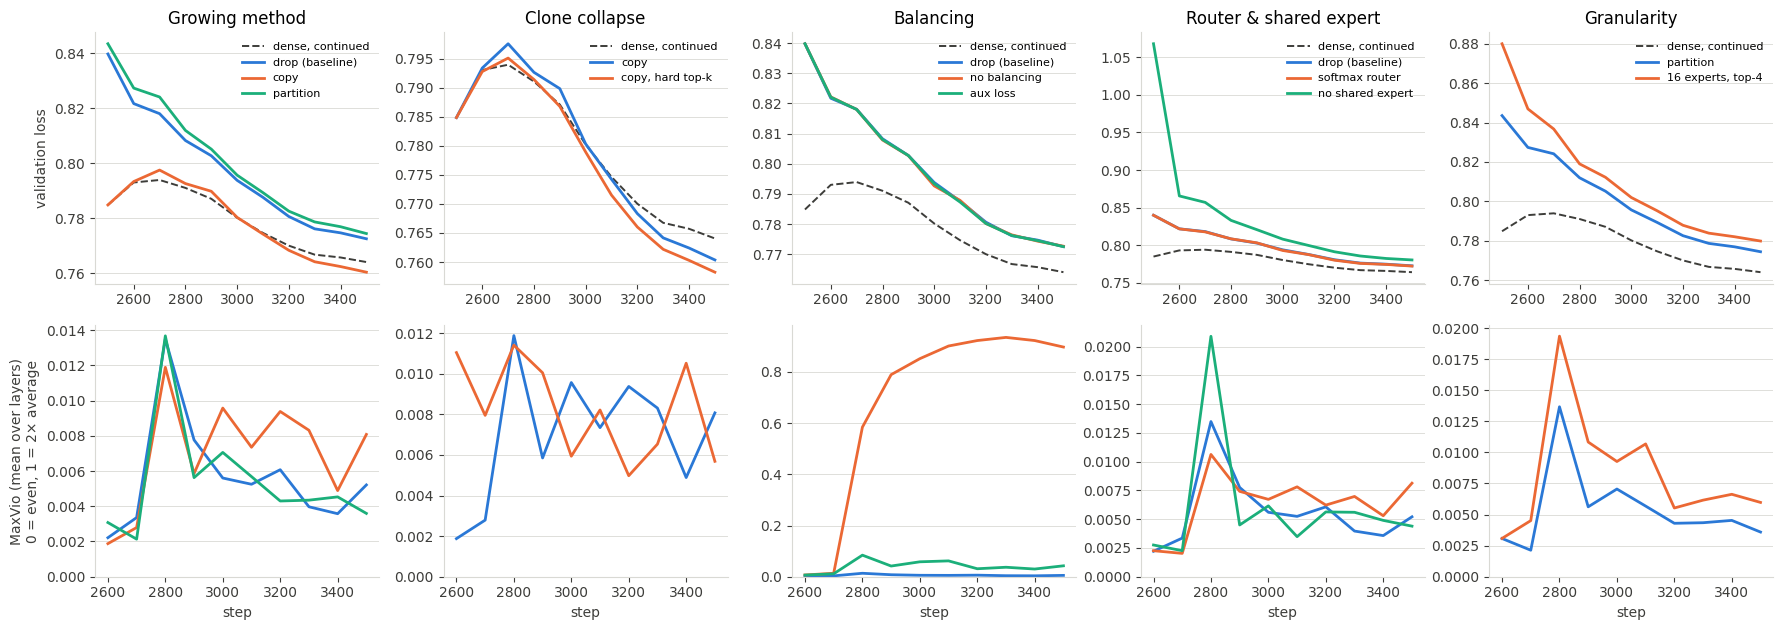

In [16]:
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
panels = {p: [v for v in vs if v in exp_logs] for p, vs in PANELS.items()}
panels = {p: vs for p, vs in panels.items() if vs}
P = len(panels)
fig, axes = plt.subplots(2, P, figsize=(3.6 * P, 6.4), squeeze=False)
for j, (title, vs) in enumerate(panels.items()):
    ax_l, ax_m = axes[0, j], axes[1, j]
    xs, ys = zip(*exp_logs["dense, continued"]["val"])
    ax_l.plot(xs, ys, color=INK, lw=1.4, ls="--", label="dense, continued")
    for i, v in enumerate(vs):
        c = SLOTS[i % len(SLOTS)]
        xs, ys = zip(*exp_logs[v]["val"])
        ax_l.plot(xs, ys, color=c, lw=2, label=v)
        st, mv, _, _ = load_stats(exp_logs[v])
        ax_m.plot(st, mv, color=c, lw=2, label=v)
    ax_l.set_title(title)
    ax_l.legend(frameon=False, fontsize=8)
    ax_m.set_ylim(bottom=0)
    for ax in (ax_l, ax_m):
        ax.grid(axis="y", color=GRID, lw=0.6)
    ax_m.set_xlabel("step")
axes[0, 0].set_ylabel("validation loss")
axes[1, 0].set_ylabel("MaxVio (mean over layers)\n0 = even, 1 = 2× average")
plt.tight_layout(); plt.savefig("experiments.png", dpi=150, bbox_inches="tight"); plt.show()

### Reading the results

* **Jump at conversion.** `copy` should be about 0. `drop` and `partition` trade a small bump for experts that start out different.
* **vs dense continued.** Negative means the MoE beat the dense model for the same number of steps.
* **MaxVio and dead experts.** "no balancing" and "copy, hard top-k" are the ones to watch. A high *peak* with a low *final* value means collapse started and was recovered.
* **Granularity.** Compare the two partition rows only: they have the same active size.

Download `experiments.csv`, `experiments.png`, `dense.pt` and `moe.pt` from the Files panel before the Colab session ends.